# Superstore Sales Analysis

**Author:** Eman Mahmoud Ahmed Ali Omar
**Mentor:** Ali Mohamed — Gulf Plastics Industries (GPI)
**Date:** 2026-09-16
**Dataset:** [Superstore Sales Dataset](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) (9,994 rows, 2014-01-03 to 2017-12-30)

## Project Objective

This project analyzes four years of Superstore sales to identify which products, regions, and customer segments drive the most revenue and profit, and to flag areas where sales and profit diverge — specifically, where high sales come with low or negative profit.

## Analysis Questions

1. **Which product categories and regions generate the most revenue and profit?** *(bar chart)*
2. **How have sales and profit changed over time (monthly/yearly)?** *(line chart)*
3. **How does discount level relate to profit?** *(scatter plot + correlation)*

## Tools

Python, pandas, matplotlib, seaborn, sqlite3

> Checklist: All imports at the top (item 4), no hardcoded absolute paths (item 5), runs top-to-bottom on fresh clone (item 3).

## Section 1: Setup

Importing required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_style("whitegrid")
%matplotlib inline

# Consistent style for all charts
plt.rcParams["figure.dpi"] = 150

## Section 2: Load Cleaned Data

Loading the cleaned dataset. Cleaning steps are documented in `notebooks/02_cleaning.ipynb` and consolidated here for reproducibility if needed.

In [2]:
# Load cleaned data (preferred)
try:
    df = pd.read_csv("data/superstore_clean.csv", parse_dates=["Order Date", "Ship Date"])
except FileNotFoundError:
    # Fallback: load raw and apply minimal cleaning inline
    df = pd.read_csv("data/superstore.csv", encoding="latin-1")
    df["Order Date"] = pd.to_datetime(df["Order Date"])
    df["Ship Date"] = pd.to_datetime(df["Ship Date"])
    for col in ["Category", "Sub-Category", "Region", "Segment"]:
        df[col] = df[col].astype(str).str.strip()

print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 9994 rows, 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Section 3: Quick Overview of the Data

Confirming data types, summary statistics, and that no missing values remain.

In [3]:
print(df.dtypes)
print()
print(df.describe())
print()
print(df.isnull().sum())
print()
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

            Row ID                  Order Date                   Ship Date  \
count  9994.000000                        9994                        9994   
mean   4997.500000  2016-04-30 00:07:12.259355  2016-05-03 23:06:58.571142   
min       1.000000         2014-01-03 00:00:00         2014-01-07 00:00:00   
2

## Section 4: Question 1 — Which product categories and regions generate the most revenue and profit?

> **Why it matters:** Identifying top-performing categories and regions tells the business where to focus inventory, marketing, and sales effort, and reveals whether high sales come with low profit.

### 4a. Compute the answer

Total sales and profit by Category and Region, sorted descending.

In [4]:
# TODO: Compute Q1
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
cat_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

print("Sales by Category:")
print(cat_sales)
print("\nProfit by Category:")
print(cat_profit)
print("\nSales by Region:")
print(region_sales)
print("\nProfit by Region:")
print(region_profit)

# Descriptive stats for context
print("\nDescriptive stats — Sales:")
print(df["Sales"].describe())

Sales by Category:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Profit by Category:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

Sales by Region:
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

Profit by Region:
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

Descriptive stats — Sales:
count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64


### 4b. Visualize

Bar chart of total sales and profit by category/region.

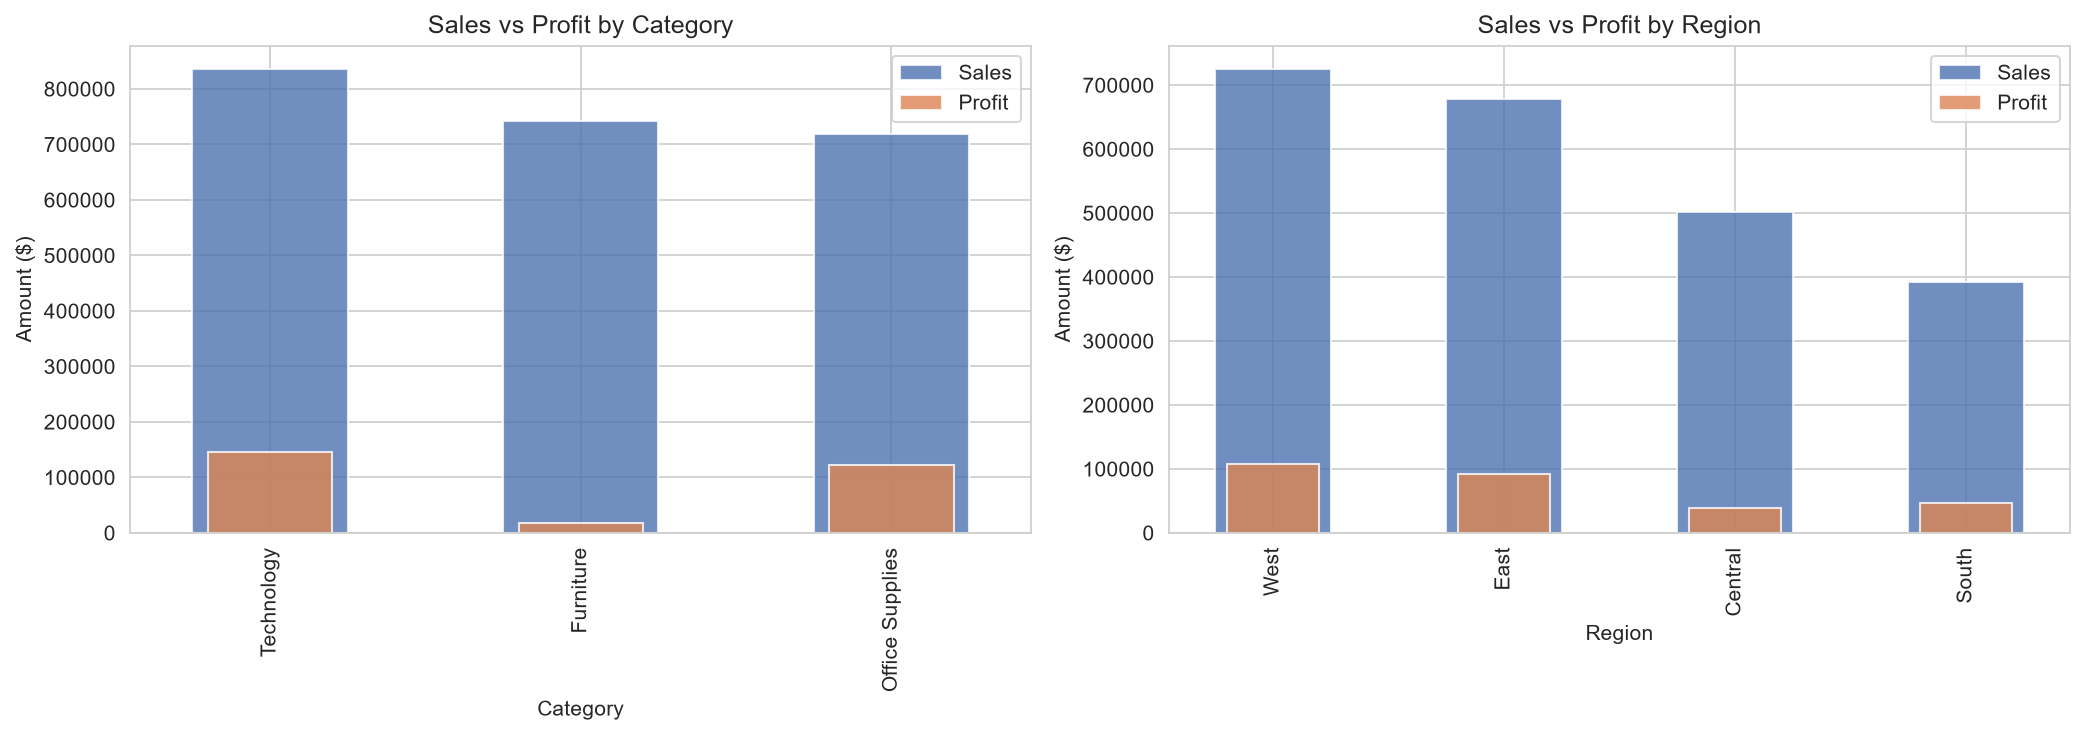

In [5]:
# TODO: Bar chart Q1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_sales.plot(kind="bar", ax=axes[0], color="#4C72B0", alpha=0.8, label="Sales")
cat_profit.reindex(cat_sales.index).plot(kind="bar", ax=axes[0], color="#DD8452", alpha=0.8, label="Profit", width=0.4)
axes[0].set_title("Sales vs Profit by Category")
axes[0].set_ylabel("Amount ($)")
axes[0].legend()

region_sales.plot(kind="bar", ax=axes[1], color="#4C72B0", alpha=0.8, label="Sales")
region_profit.reindex(region_sales.index).plot(kind="bar", ax=axes[1], color="#DD8452", alpha=0.8, label="Profit", width=0.4)
axes[1].set_title("Sales vs Profit by Region")
axes[1].set_ylabel("Amount ($)")
axes[1].legend()

plt.tight_layout()
plt.savefig("images/question1_revenue_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

### 4c. Interpret


Technology leads in both total sales ($836,154) and total profit ($145,455), 
making it the strongest overall category. However, the ranking diverges for 
the other two: Furniture has the second-highest sales ($741,999) but by far 
the lowest profit ($18,451) — a profit margin of only ~2.5%, compared to 
~17% for both Technology and Office Supplies. This means Furniture drives 
meaningful revenue but contributes almost nothing to overall profit.

Regionally, West and East consistently lead in both sales and profit. 
Central shows the same divergence pattern as Furniture: its sales 
($501,240) rank third, close to East, but its profit ($39,706) is the 
lowest of all four regions — a margin of only ~7.9%, versus ~15% for West 
and ~13.5% for East.

**Business implication:** Furniture and the Central region should be 
investigated further (e.g., discount levels, product mix, shipping costs) 
since they generate substantial revenue without translating it into 
proportional profit.

## Section 5: Question 2 — How have sales and profit changed over time?

> **Why it matters:** Trend over 4 years shows whether the business is growing, shrinking, or seasonal — affects forecasting and planning.

### 5a. Compute the answer

Monthly and yearly aggregation.

In [6]:
# TODO: Compute Q2
# df["Order Date"] = pd.to_datetime(df["Order Date"])
monthly = df.groupby(pd.Grouper(key="Order Date", freq="ME"))[["Sales", "Profit"]].sum()
yearly = df.groupby(df["Order Date"].dt.year)[["Sales", "Profit"]].sum()
print(monthly.head())
print(yearly)

                Sales     Profit
Order Date                      
2014-01-31  14236.895  2450.1907
2014-02-28   4519.892   862.3084
2014-03-31  55691.009   498.7299
2014-04-30  28295.345  3488.8352
2014-05-31  23648.287  2738.7096
                  Sales      Profit
Order Date                         
2014        484247.4981  49543.9741
2015        470532.5090  61618.6037
2016        609205.5980  81795.1743
2017        733215.2552  93439.2696


### 5b. Visualize

Line chart of sales/profit over time. Line chart is required for time-based question.

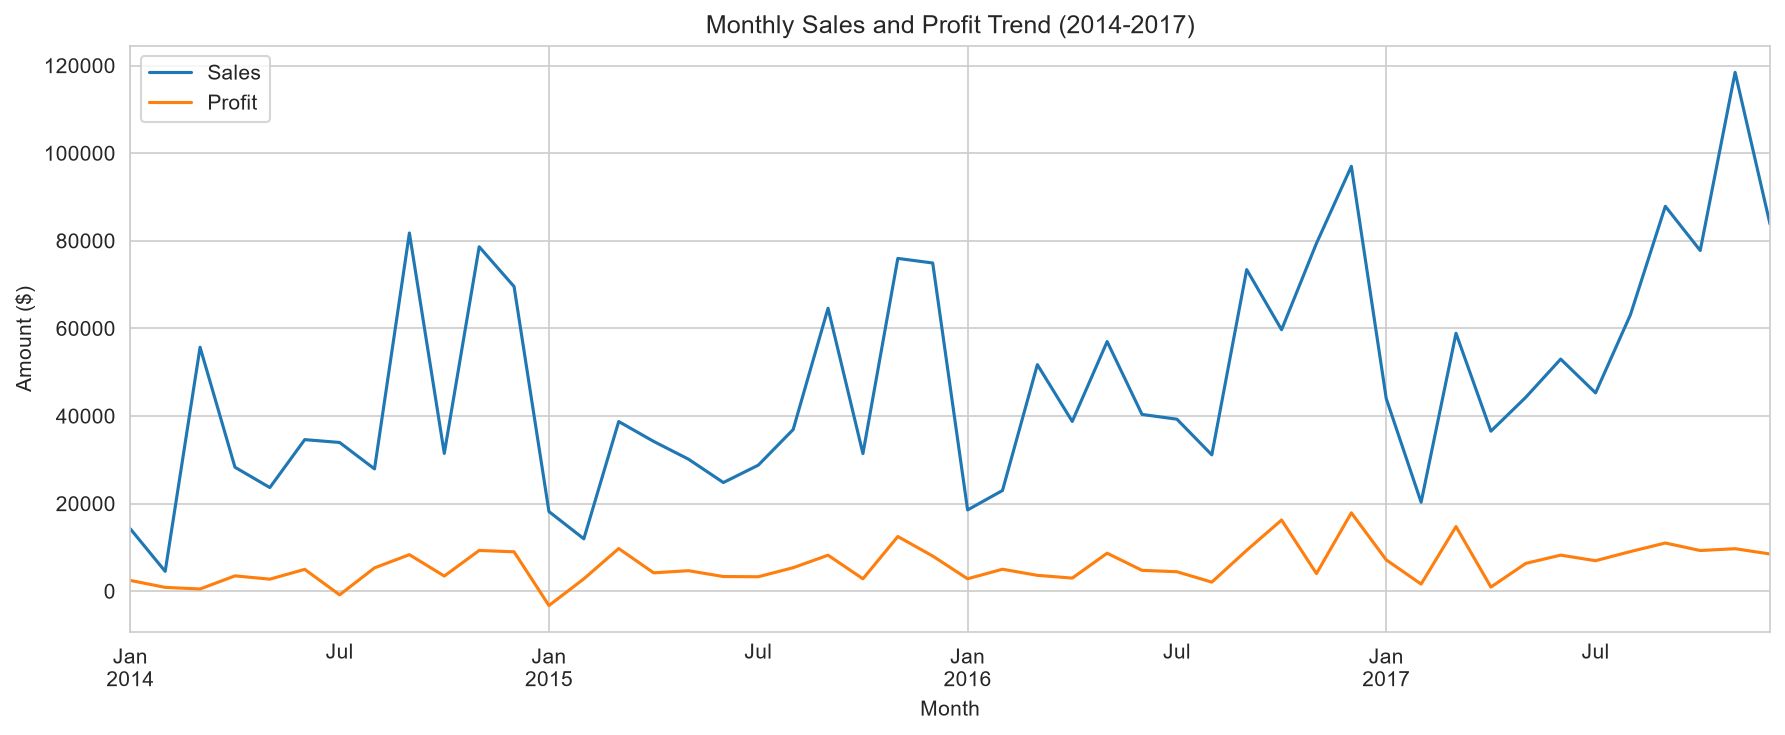

In [7]:
#Line chart Q2
plt.figure(figsize=(12, 5))
monthly["Sales"].plot(label="Sales")
monthly["Profit"].plot(label="Profit")
plt.title("Monthly Sales and Profit Trend (2014-2017)")
plt.xlabel("Month")
plt.ylabel("Amount ($)")
plt.legend()
plt.tight_layout()
plt.savefig("images/question2_sales_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

### 5c. Interpret


Sales grew from $484,247 in 2014 to $733,215 in 2017 — an increase of 
about 51%, while profit grew even faster, from $49,544 to $93,439 
(about 89%), showing improved efficiency over time, not just higher 
volume. The monthly trend reveals clear seasonality: each year starts 
with a low in January and builds to a peak around November/December 
(the highest point in the dataset, ~$118,000, occurs in November 2017). 
This pattern repeats consistently across all four years.

This growth was expected given the multi-year trend, but the strength 
and consistency of the year-end seasonal spike was more pronounced than 
anticipated. 

**Business implication:** Inventory and staffing should be planned 
around the consistent Q4 demand spike, and the January slowdown each 
year should be anticipated rather than treated as a warning sign.

## Section 6: Question 3 — How does discount level relate to profit?

> **Why it matters:** Discounts drive volume but can erode margins. This determines discount policy.

### 6a. Compute the answer

Correlation and grouped comparison (discount bins vs avg profit).

In [8]:
#Compute Q3
print(df[["Discount", "Profit"]].corr())
discount_bins = pd.cut(df["Discount"], bins=[-0.01, 0, 0.2, 0.4, 0.8])
print(df.groupby(discount_bins)["Profit"].agg(["mean", "median", "count"]))
print(f"Profit mean: {df['Profit'].mean():.2f}, median: {df['Profit'].median():.2f}")

          Discount    Profit
Discount  1.000000 -0.219487
Profit   -0.219487  1.000000
                    mean   median  count
Discount                                
(-0.01, 0.0]   66.900292  15.9952   4798
(0.0, 0.2]     26.501571   6.7450   3803
(0.2, 0.4]    -77.864055 -36.1146    460
(0.4, 0.8]   -106.708028 -13.5800    933
Profit mean: 28.66, median: 8.67


### 6b. Visualize

Scatter plot (discount vs profit) — third required chart type. Optionally add boxplot by discount bin.

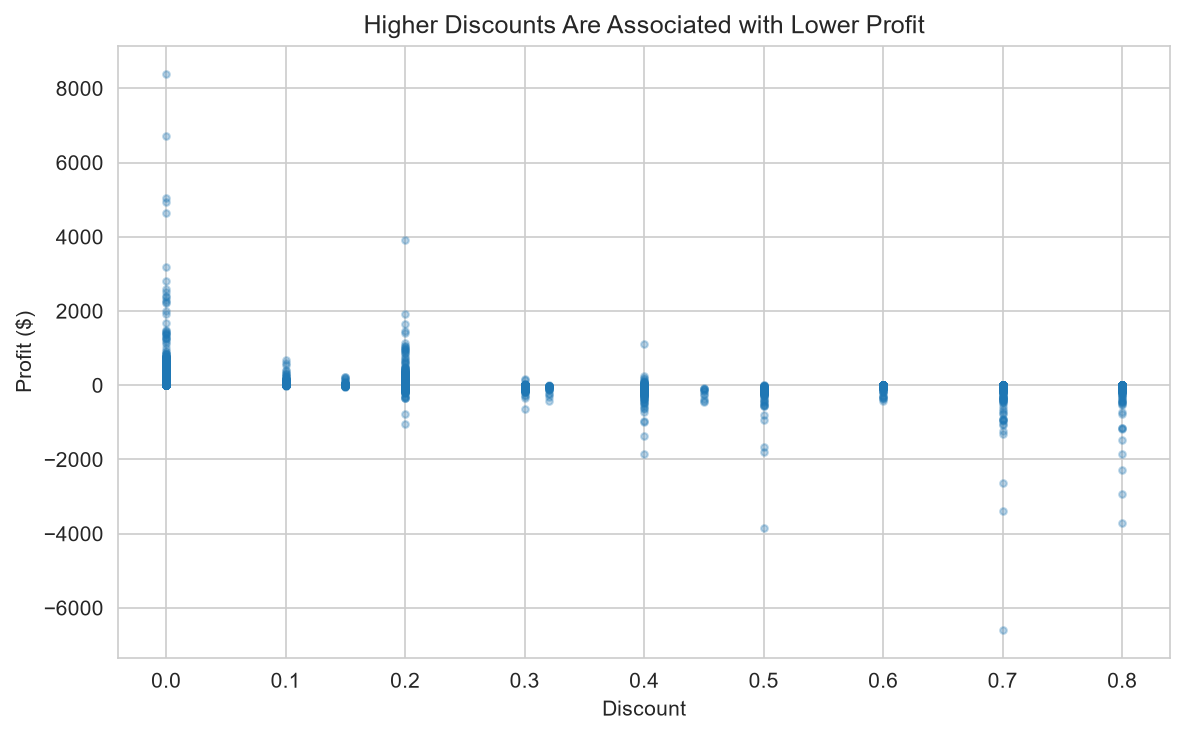

In [9]:
#Scatter Q3
plt.figure(figsize=(8, 5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.3, s=10)
plt.title("Higher Discounts Are Associated with Lower Profit")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.savefig("images/question3_discount_vs_profit.png", dpi=150, bbox_inches="tight")
plt.show()

### 6c. Interpret


The overall correlation between Discount and Profit is -0.22 — a weak-to-
moderate negative relationship. However, this understates the real 
pattern: grouping orders by discount level reveals a clear threshold 
effect. Orders with 0% discount average $66.90 profit, and orders with 
up to 20% discount still average a positive $26.50. But once discount 
exceeds 20%, average profit turns negative: -$77.86 for the 20-40% range 
and -$106.71 for discounts above 40%. In other words, discounts up to 
20% reduce margin but remain profitable on average, while discounts 
above 20% cause outright losses on most orders.

**Business implication:** The 20% discount threshold should be treated 
as a soft policy limit. Discounts above this level should require 
explicit justification (e.g., clearing old inventory) since they are, 
on average, unprofitable.

## Section 7: Additional Analysis — Boxplot + Outliers (Required for Q7)

> **Mentor decision (Q7):** Boxplot is required here to satisfy checklist item 15 (3 chart types: bar, line, scatter + boxplot as 4th). This section satisfies the "at least one correlation or outlier investigation tied to analysis" requirement.
> Locked scope (Q8): Stay at **3 questions** — this section is supporting insight only, not a 4th question.

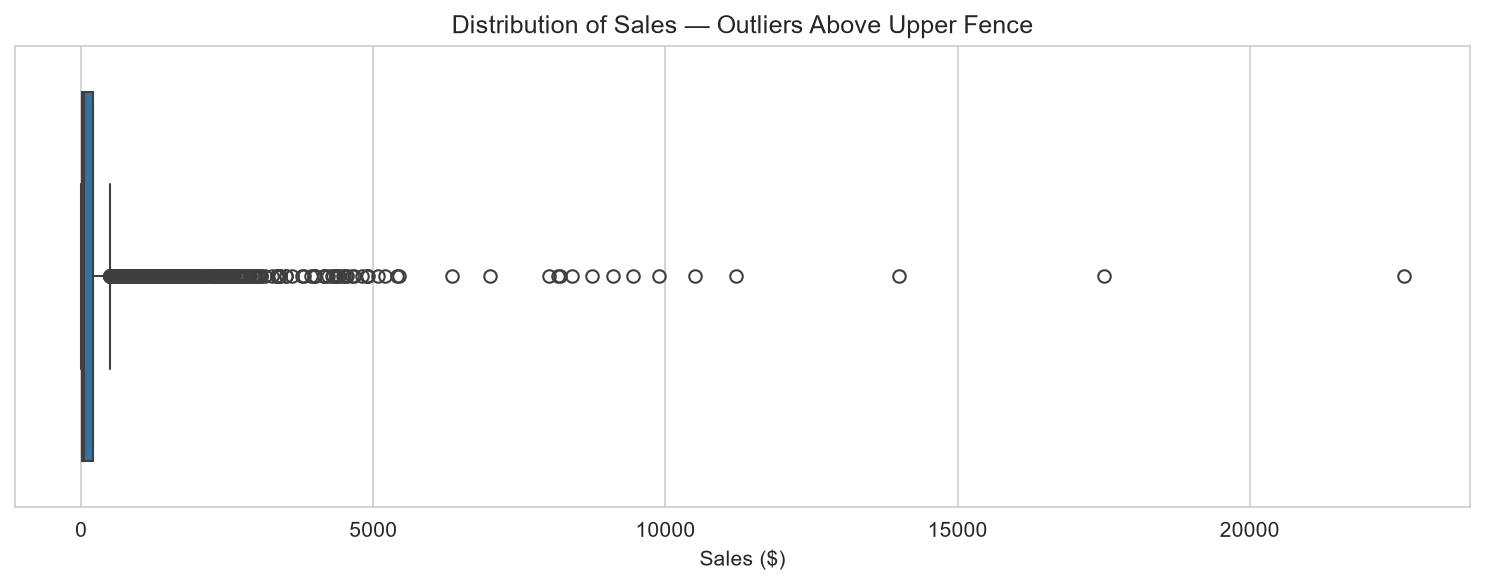

Sales outliers: 1167 (11.7% of orders)
Upper fence: $498.93, total sales in outliers: $1,477,483
Outlier orders are concentrated in: {'Furniture': 467, 'Technology': 400, 'Office Supplies': 300}


In [10]:
# REQUIRED (Q7): Boxplot + IQR outlier check — 4th chart type
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Sales"])
plt.title("Distribution of Sales — Outliers Above Upper Fence")
plt.xlabel("Sales ($)")
plt.tight_layout()
plt.savefig("images/additional_sales_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5*IQR
outliers = df[df["Sales"] > upper]
print(f"Sales outliers: {len(outliers)} ({len(outliers)/len(df):.1%} of orders)")
print(f"Upper fence: ${upper:.2f}, total sales in outliers: ${outliers['Sales'].sum():,.0f}")
print(f"Outlier orders are concentrated in: {outliers['Category'].value_counts().head(3).to_dict()}")

### Interpretation

11.7% of orders (1,167 out of 9,994) are statistical outliers in Sales, 
with values above the $498.93 upper fence. These outliers alone account 
for $1,477,483 — roughly two-thirds of total sales — showing that a 
relatively small number of large orders drive most revenue. Notably, 
Furniture has the highest count of outlier orders (467), more than 
Technology (400) or Office Supplies (300), despite being the weakest 
category in overall profit margin (Q1). This suggests Furniture's large 
orders are not converting into proportional profit, reinforcing the 
Q1 finding.

## Section 8: Findings

> This is the source of truth for `findings.md`. Write 5–8 findings, each grounded in a specific number from the sections above (checklist items 17-21). Keep it in plain English.

### Findings

1. **Technology leads in both sales and profit.** Technology generated 
$836,154 in sales (36% of $2,297,201 total) and $145,455 in profit — 
the strongest category on both metrics. Source: Q1.

2. **Furniture drives high sales but almost no profit.** Furniture ranks 
2nd in sales ($741,999) but last in profit ($18,451) — a margin of only 
~2.5%, versus ~17% for Technology and Office Supplies. Source: Q1.

3. **West region leads in both sales and profit** — $725,458 sales, 
$108,418 profit — the strongest region overall. Source: Q1.

4. **Central region shows the same divergence pattern as Furniture.** 
Central ranks 3rd in sales ($501,240) but has the lowest profit margin 
of all regions (~7.9%, vs ~15% for West). Source: Q1.

5. **Sales and profit grew steadily from 2014 to 2017, with profit 
growing faster than sales.** Sales rose 51% ($484,247 → $733,215) while 
profit rose 89% ($49,544 → $93,439), indicating improved efficiency over 
time, not just volume growth. Source: Q2.

6. **Clear year-end

## Section 9: Limitations



This dataset covers only four years (2014–2017), so trend conclusions 
should be treated as short-term patterns rather than long-term forecasts. 
The data also lacks cost or marketing spend information, meaning "Profit" 
here reflects revenue minus discount effects but not true operating 
margin — we cannot separate the impact of shipping costs, overhead, or 
promotional spend. Geography is limited to state/region level, so 
store-level or city-level profitability cannot be assessed. Finally, the 
discount-profit relationship shown here is correlational, not causal — 
other factors (e.g., product type, order size) may also drive the 
pattern observed at higher discount levels.

## Section 10: Conclusion

Across the three analysis questions, one theme stands out clearly: 
sales volume does not guarantee profit. Technology is the strongest 
performer on both fronts, but Furniture and the Central region generate 
substantial revenue while contributing very little profit — largely 
tied to a smaller number of large, heavily discounted orders. The 
business grew consistently from 2014 to 2017, with profit growing even 
faster than sales, and demand follows a predictable seasonal pattern 
peaking each Q4. However, discounts above 20% are, on average, 
unprofitable, and this — combined with Furniture's weak margins — 
represents the clearest actionable opportunity: tightening discount 
policy above 20% and reviewing Furniture's pricing or cost structure 
could meaningfully improve overall profitability without needing new 
sales volume.

With more time, the next step would be to break this down further by 
Sub-Category and Customer Segment to pinpoint exactly which products or 
customer types are driving the Furniture and Central region losses, and 
whether the same 20% discount threshold holds across all categories.

## Section 11: Quality Checklist Before Submission

- [ ] Every section has a markdown heading
- [ ] Every code cell has a one-line markdown explanation above it
- [ ] Every chart has a title, axis labels, and 2–3 sentence Interpretation
- [ ] At least one chart exported as PNG and saved in `images/`
- [ ] Findings section has 5–8 numbered findings, each with a specific number
- [ ] Limitations section has at least one honest paragraph
- [ ] Notebook runs top-to-bottom without errors on a fresh clone (Kernel → Restart & Run All)

> Self-review against `Final_Project_Checklist.md` — all 36 items must be ticked.